# Cognitive Lab D3 — Biosignal EDA, Sync & Periodicity Check

**Read this first — two caveats that shape every interpretation below:**

1. **Files are whitespace-delimited** (`sep=r"\s+"`), NOT tab. Mouse/keyboard CSVs are
   comma-delimited and use a `time` column instead of `Timestamp`.
2. **Amplitudes are pre-scaled, not physical units** (EDA ~ -49, RIP ~ -49.99, EEG ~ -37,
   fNIRS ~ 1e-3). You therefore CANNOT compare raw amplitudes to clinical reference ranges
   (uS, mV, breaths/min by amplitude). What you CAN compare are RATE / FREQUENCY features
   (heart rate from ECG peaks, respiration rate from RIP spectrum, EEG band ratios), because
   those survive any linear rescaling. See the final cell.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

DATASET_DIR = os.path.expanduser("~/biosignals_data/cog_lab")
SIGNALS = ["ACC", "ECG", "EDA", "EEG", "fNIRS", "RIP"]
EXCLUDE = {"S2"}          # S2 has no HCI folder; recap excludes it. Empty the set to include it.

def list_subjects(root):
    subs = [d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and d.startswith("S") and d[1:].isdigit()]
    subs.sort(key=lambda s: int(s[1:]))           # natural sort S1, S2, ... S18
    return subs

def bio_path(root, sid, sig):
    return os.path.join(root, sid, "Biosignals", f"D3_{sid}_{sig}.txt")

def load_bio(path):
    # WHITESPACE separated; first column is Timestamp. This is the fix for your KeyError.
    return pd.read_csv(path, sep=r"\s+")

def load_hci(root, sid, kind):
    # mouse / keyboard: COMMA separated, time column (NOT Timestamp)
    p = os.path.join(root, sid, "HCI", f"D3_{sid}_{kind}.csv")
    return pd.read_csv(p) if os.path.exists(p) else None

subjects = [s for s in list_subjects(DATASET_DIR) if s not in EXCLUDE]
print(f"{len(subjects)} subjects:", subjects)

17 subjects: ['S1', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18']


## 1. Per-signal summary: length, sampling rate, NaNs, dropped-sample gaps

In [2]:
rows = []
for sid in subjects:
    for sig in SIGNALS:
        p = bio_path(DATASET_DIR, sid, sig)
        if not os.path.exists(p):
            rows.append(dict(subject=sid, signal=sig, exists=False))
            continue
        df = load_bio(p)
        ts = df["Timestamp"].to_numpy(dtype=float)
        dt = np.diff(ts)
        fs = 1.0 / np.median(dt) if len(dt) else np.nan
        valcols = [c for c in df.columns if c != "Timestamp"]
        gap_thresh = 5 * np.median(dt) if len(dt) else np.inf
        rows.append(dict(
            subject=sid, signal=sig, exists=True,
            n=len(df), fs=round(fs, 2),
            start=ts.min(), end=ts.max(), dur_s=round(ts.max() - ts.min(), 1),
            nan=int(df[valcols].isna().sum().sum()),
            n_gaps=int((dt > gap_thresh).sum()),       # number of dropped-sample gaps
            max_gap_s=round(float(dt.max()), 2) if len(dt) else np.nan,
            cols=",".join(valcols),
        ))
summary = pd.DataFrame(rows)
summary

,subject,signal,exists,n,fs,start,end,dur_s,nan,n_gaps,max_gap_s,cols
0,S1,ACC,True,144303,100.0,1.683027e+09,1.683028e+09,1443.0,0,0,0.01,"ACC_x,ACC_y,ACC_z"
1,S1,ECG,True,144303,100.0,1.683027e+09,1.683028e+09,1443.0,0,0,0.01,ECG
2,S1,EDA,True,144303,100.0,1.683027e+09,1.683028e+09,1443.0,0,0,0.01,EDA
3,S1,EEG,True,144303,100.0,1.683027e+09,1.683028e+09,1443.0,0,0,0.01,"EEG_AF7,EEG_AF8"
4,S1,fNIRS,True,199849,100.0,1.683026e+09,1.683028e+09,1998.5,0,0,0.01,"fNIRS_red_AF7,fNIRS_infrared_AF7,fNIRS_red_AF8..."
...,...,...,...,...,...,...,...,...,...,...,...,...
97,S18,ECG,True,265300,100.0,1.683803e+09,1.683805e+09,2653.0,0,0,0.01,ECG
98,S18,EDA,True,265300,100.0,1.683803e+09,1.683805e+09,2653.0,0,0,0.01,EDA
99,S18,EEG,True,265300,100.0,1.683803e+09,1.683805e+09,2653.0,0,0,0.01,"EEG_AF7,EEG_AF8"
100,S18,fNIRS,True,305920,100.0,1.683802e+09,1.683805e+09,3059.2,0,0,0.01,"fNIRS_red_AF7,fNIRS_infrared_AF7,fNIRS_red_AF8..."


## 2. Cross-signal alignment — does every stream start at the same instant?
`offset_s` = how many seconds after the earliest stream each signal begins, per subject.
Anything non-zero (e.g. fNIRS in S1) means you MUST align on Timestamp, not by row index.

In [3]:
piv_start = summary[summary.exists].pivot(index="subject", columns="signal", values="start")
ref = piv_start.min(axis=1)
offsets = piv_start.sub(ref, axis=0).round(1)
offsets["session_dur_s"] = summary[summary.exists].groupby("subject")["dur_s"].max()
offsets

signal,ACC,ECG,EDA,EEG,RIP,fNIRS,session_dur_s
subject,,,,,,,
S1,529.7,529.7,529.7,529.7,529.7,0.0,1998.5
S10,108.8,108.8,108.8,108.8,108.8,0.0,1710.0
S11,380.9,380.9,380.9,380.9,380.9,0.0,1719.7
S12,325.1,325.1,325.1,325.1,325.1,0.0,2307.3
S13,251.5,251.5,251.5,251.5,251.5,0.0,1467.2
S14,254.2,254.2,254.2,254.2,254.2,0.0,2090.1
S15,333.9,333.9,333.9,333.9,333.9,0.0,1654.5
S16,253.8,253.8,253.8,253.8,253.8,0.0,1643.3
S17,529.7,529.7,529.7,529.7,529.7,0.0,1998.5


## 3. Session length across subjects

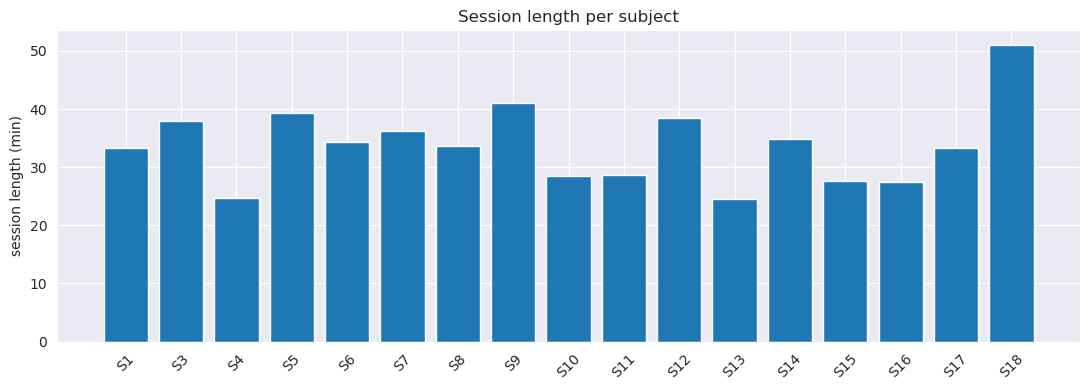

count    17.000000
mean     33.803529
std       6.749396
min      24.453333
25%      28.500000
50%      33.695000
75%      37.883333
max      50.986667
Name: dur_s, dtype: float64


In [4]:
dur = summary[summary.exists].groupby("subject")["dur_s"].max().reindex(subjects)
plt.figure(figsize=(11, 4))
plt.bar(dur.index, dur.values / 60.0)
plt.ylabel("session length (min)"); plt.xticks(rotation=45)
plt.title("Session length per subject"); plt.tight_layout(); plt.show()
print((dur / 60.0).describe())

## 4. Full-signal look for one subject (downsampled so it actually renders)

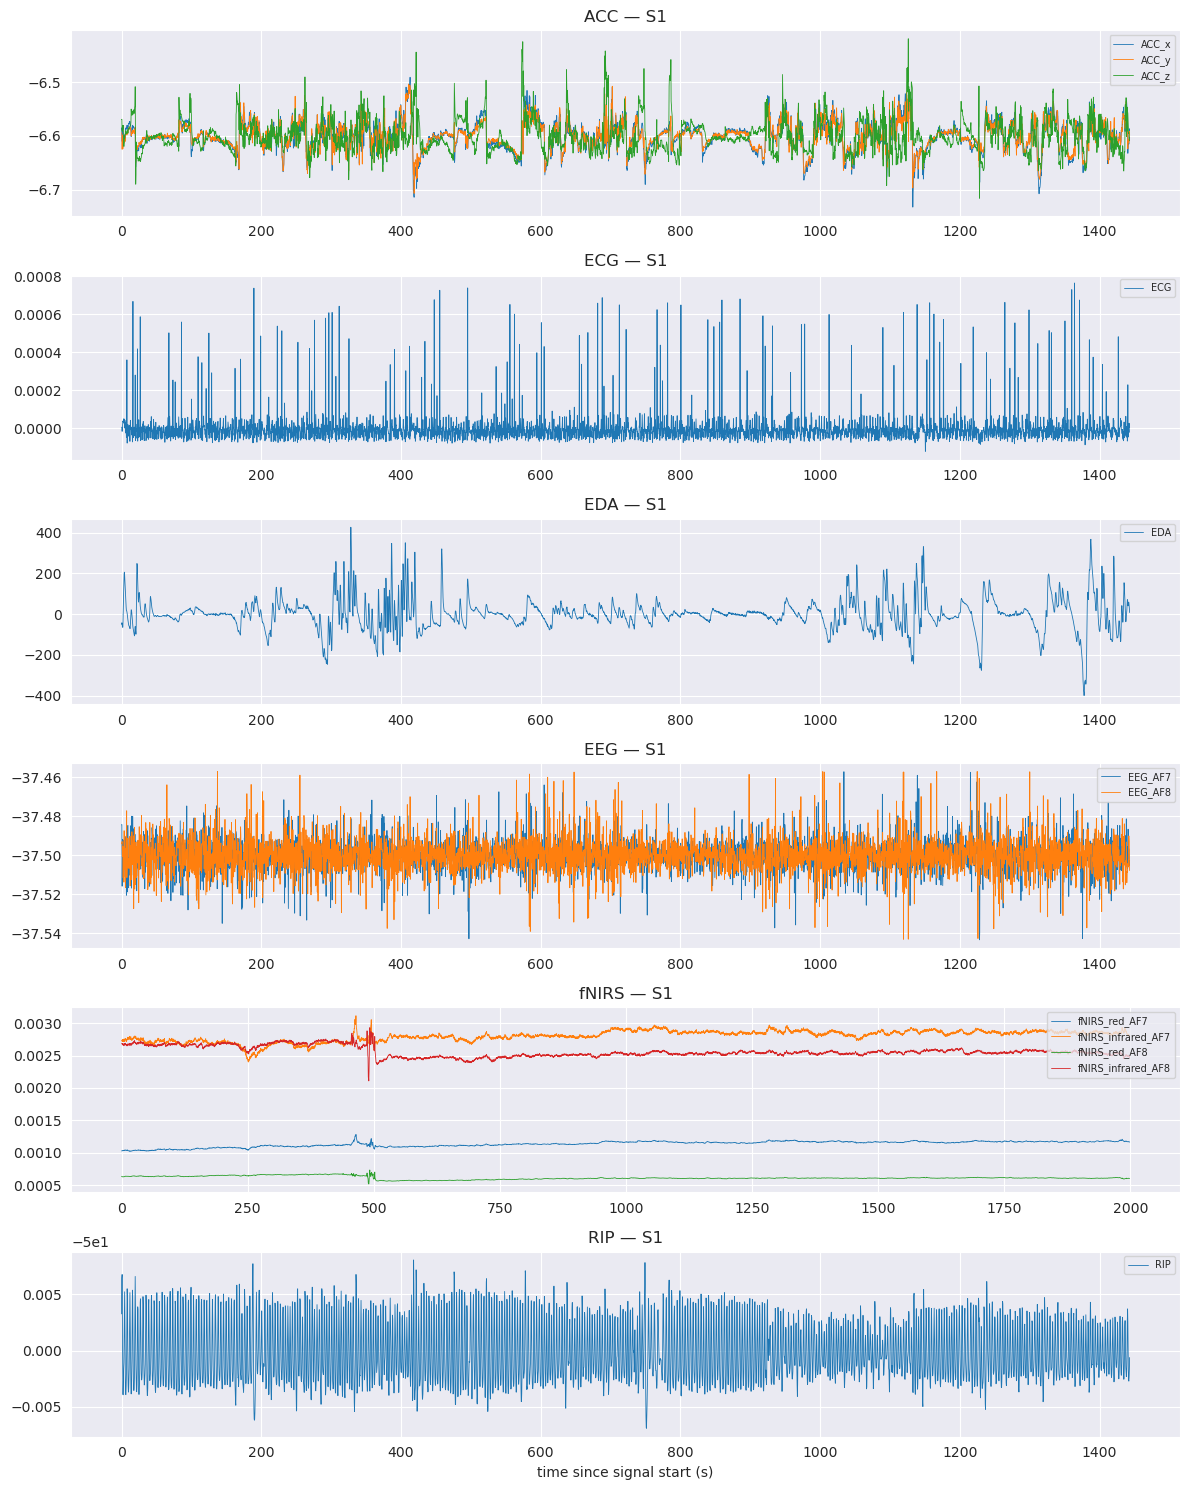

In [5]:
def plot_subject(sid, max_pts=4000):
    fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 15))
    for ax, sig in zip(axes, SIGNALS):
        p = bio_path(DATASET_DIR, sid, sig)
        if not os.path.exists(p):
            ax.set_title(f"{sig} — missing"); continue
        df = load_bio(p)
        ts = df["Timestamp"].to_numpy(float); t = ts - ts.min()
        step = max(1, len(df) // max_pts)
        for c in [c for c in df.columns if c != "Timestamp"]:
            ax.plot(t[::step], df[c].to_numpy(float)[::step], lw=0.6, label=c)
        ax.set_title(f"{sig} — {sid}"); ax.legend(loc="upper right", fontsize=7)
    axes[-1].set_xlabel("time since signal start (s)")
    plt.tight_layout(); plt.show()

plot_subject(subjects[0])

## 5. Global aspect of one channel across ALL users (z-scored heatmap)
Each user's session is resampled onto normalized time [0,1] and z-scored, so you see the
SHAPE of the signal over the session regardless of per-user scale. Try "ECG","EDA","RIP".

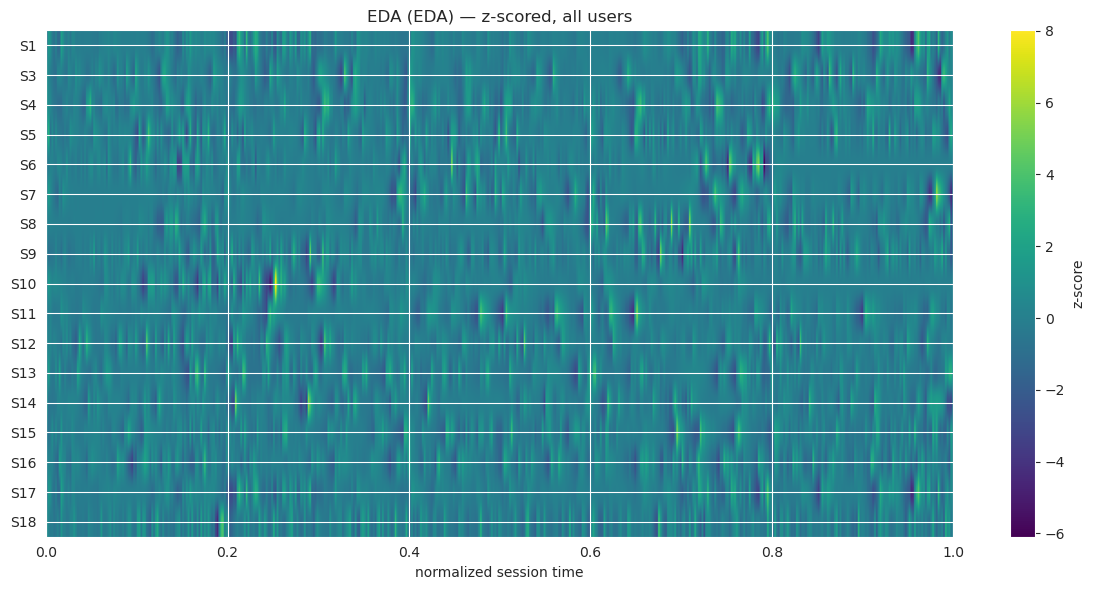

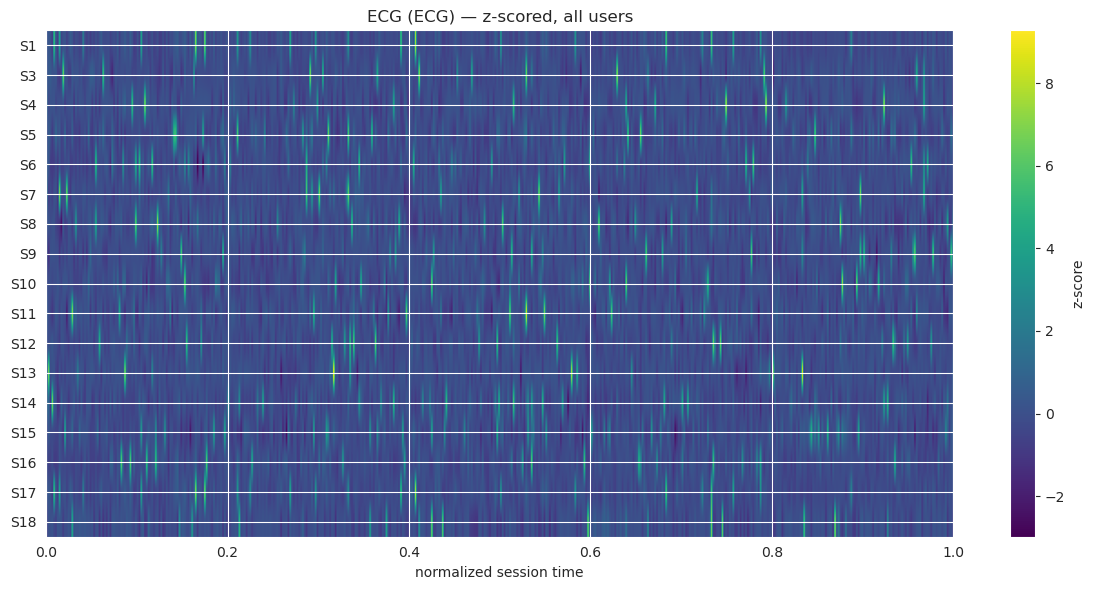

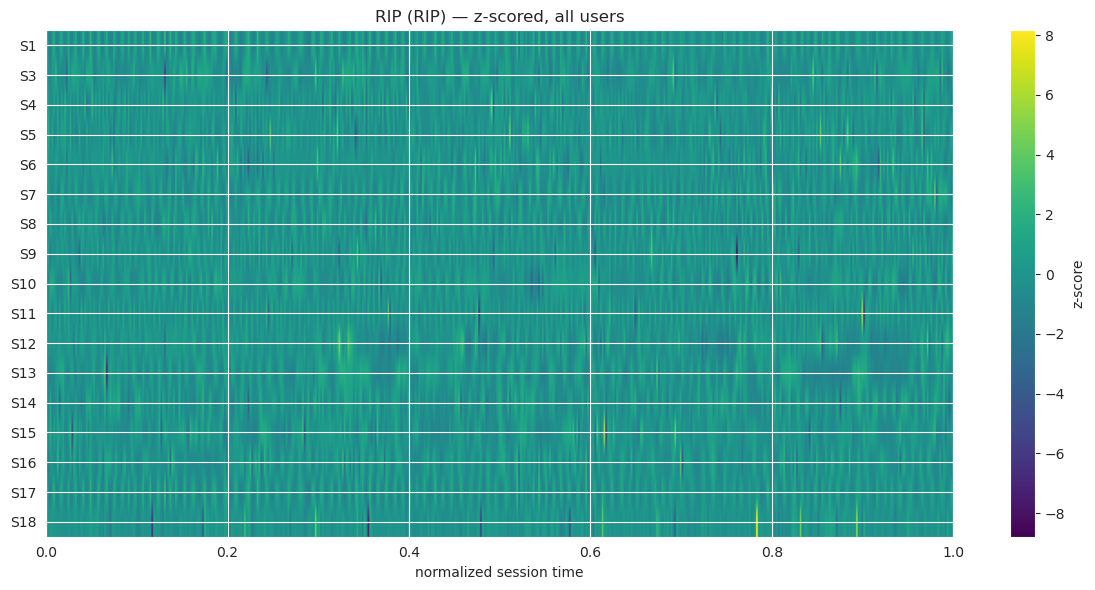

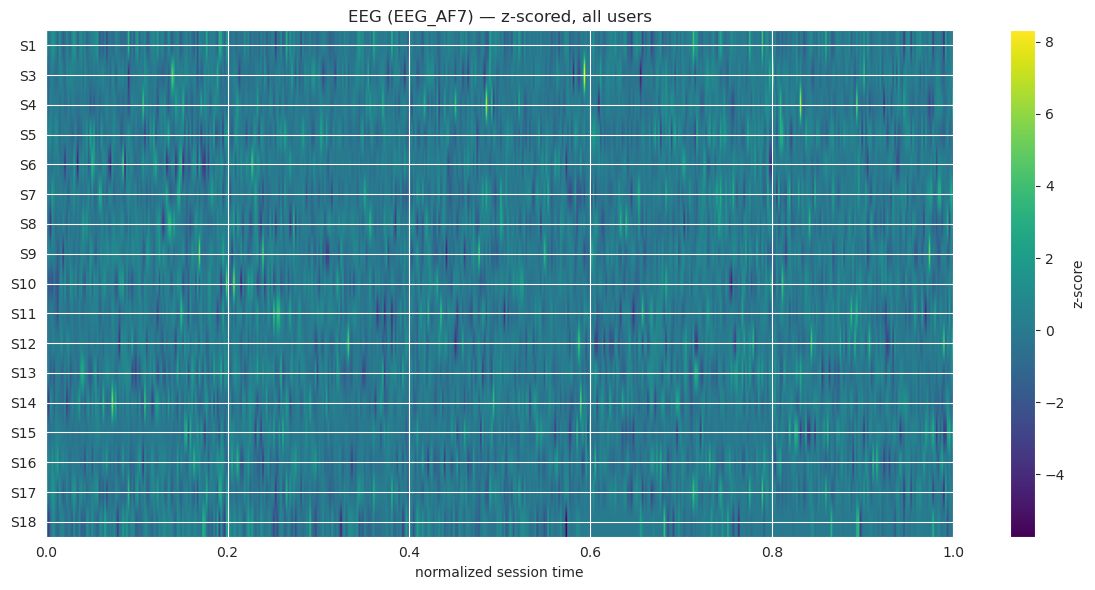

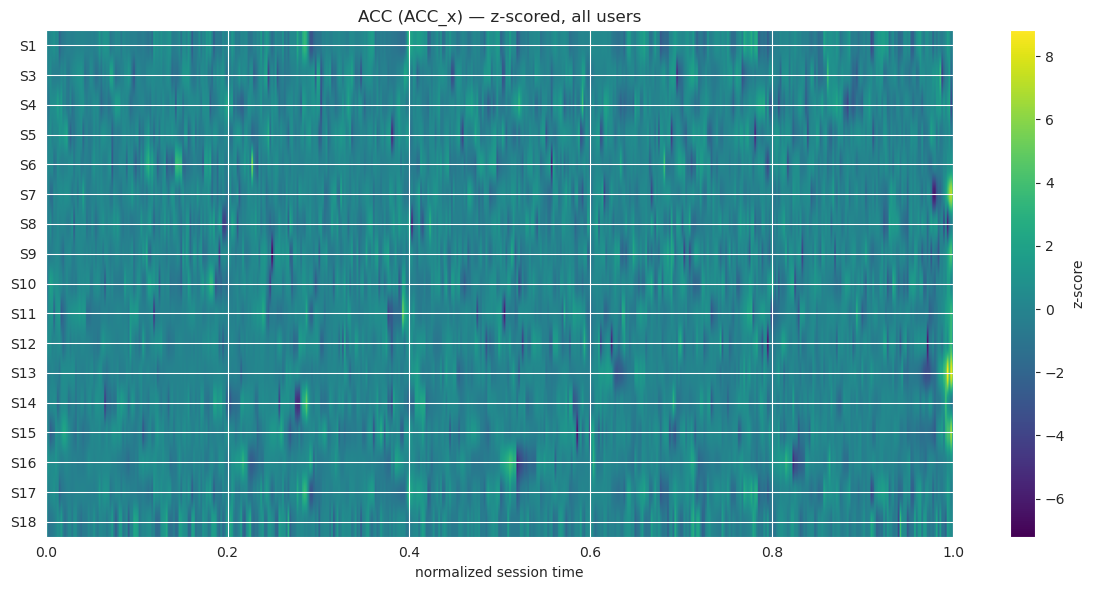

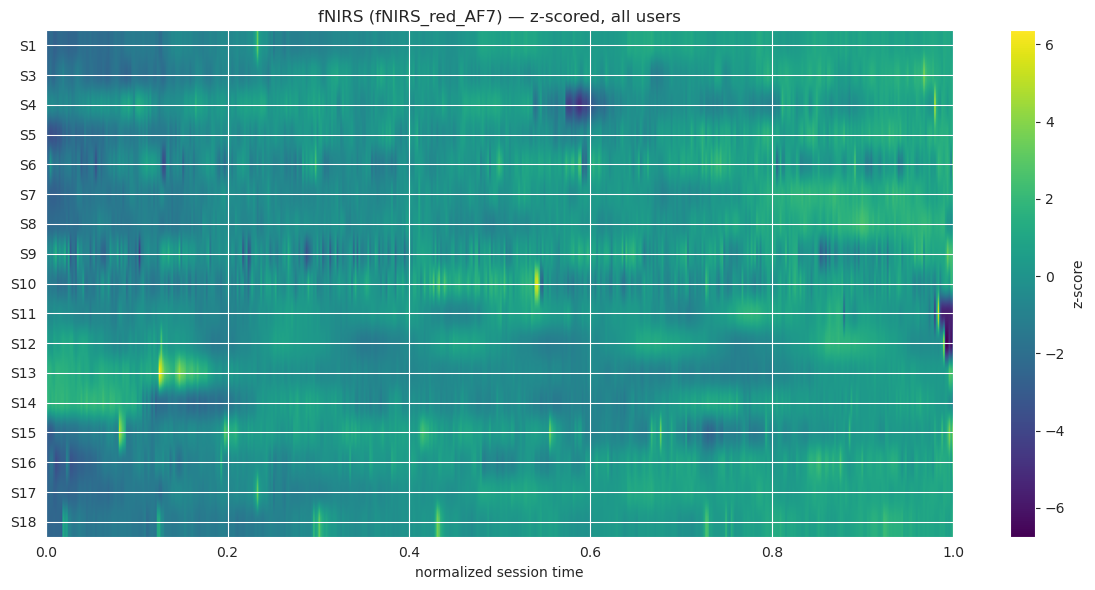

In [9]:
def cross_user_heatmap(sig="EDA", nbins=500):
    mat, labels = [], []
    for sid in subjects:
        p = bio_path(DATASET_DIR, sid, sig)
        if not os.path.exists(p):
            continue
        df = load_bio(p)
        c = [x for x in df.columns if x != "Timestamp"][0]
        v = df[c].to_numpy(float)
        ts = df["Timestamp"].to_numpy(float)
        tn = (ts - ts.min()) / (ts.max() - ts.min() + 1e-9)
        vi = np.interp(np.linspace(0, 1, nbins), tn, v)
        vi = (vi - np.nanmean(vi)) / (np.nanstd(vi) + 1e-9)
        mat.append(vi); labels.append(sid)
    mat = np.array(mat)
    plt.figure(figsize=(12, 6))
    plt.imshow(mat, aspect="auto", cmap="viridis", extent=[0, 1, len(labels), 0])
    plt.yticks(np.arange(len(labels)) + 0.5, labels)
    plt.xlabel("normalized session time"); plt.colorbar(label="z-score")
    plt.title(f"{sig} ({c}) — z-scored, all users"); plt.tight_layout(); plt.show()

cross_user_heatmap("EDA")
cross_user_heatmap("ECG")
cross_user_heatmap("RIP")
cross_user_heatmap("EEG")
cross_user_heatmap("ACC")
cross_user_heatmap("fNIRS")

## 6. Periodicity: is there a repeated rhythm, or just a fragment?
Welch PSD. A sharp peak = a real periodic rhythm (heartbeat ~1 Hz, breathing ~0.2-0.3 Hz).
Flat / 1-over-f only = no clean periodicity at that band.

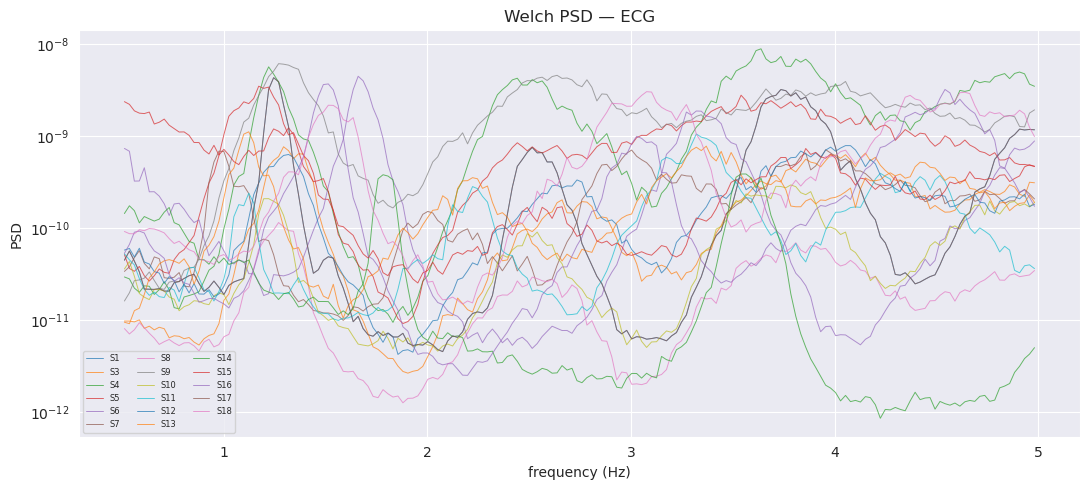

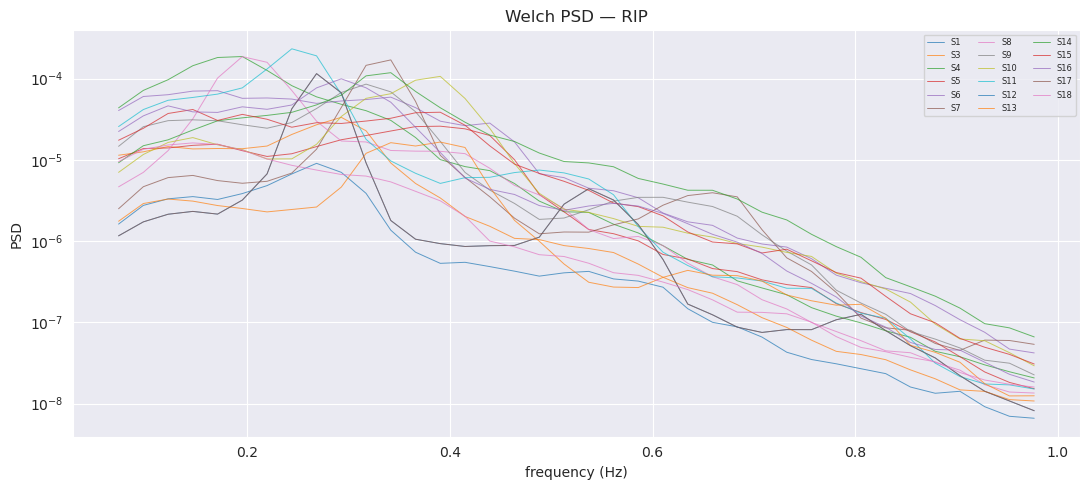

In [7]:
def psd_overlay(sig, band=None, nperseg=4096):
    plt.figure(figsize=(11, 5))
    for sid in subjects:
        p = bio_path(DATASET_DIR, sid, sig)
        if not os.path.exists(p):
            continue
        df = load_bio(p)
        c = [x for x in df.columns if x != "Timestamp"][0]
        v = df[c].to_numpy(float); v = v - np.nanmean(v)
        fs = 1.0 / np.median(np.diff(df["Timestamp"].to_numpy(float)))
        f, Pxx = signal.welch(v, fs=fs, nperseg=min(nperseg, len(v)))
        if band:
            m = (f >= band[0]) & (f <= band[1]); f, Pxx = f[m], Pxx[m]
        plt.semilogy(f, Pxx, lw=0.7, alpha=0.7, label=sid)
    plt.xlabel("frequency (Hz)"); plt.ylabel("PSD"); plt.title(f"Welch PSD — {sig}")
    plt.legend(fontsize=6, ncol=3); plt.tight_layout(); plt.show()

psd_overlay("ECG", band=(0.5, 5))     # cardiac band
psd_overlay("RIP", band=(0.05, 1))    # respiration band

## 7. Rate features that ARE comparable to references (scale-invariant)
HR from ECG R-peaks; respiration rate from RIP spectral peak. Heuristic — sanity check, not clinical.

In [8]:
def estimate_rates():
    out = []
    for sid in subjects:
        rec = {"subject": sid}
        pe = bio_path(DATASET_DIR, sid, "ECG")
        if os.path.exists(pe):
            df = load_bio(pe); v = df["ECG"].to_numpy(float)
            ts = df["Timestamp"].to_numpy(float); fs = 1.0 / np.median(np.diff(ts))
            vz = (v - v.mean()) / (v.std() + 1e-9)
            peaks, _ = find_peaks(vz, distance=int(0.4 * fs), height=2.0)   # <150 bpm, >2 SD
            if len(peaks) > 1:
                rec["HR_bpm"] = round(60.0 / np.median(np.diff(ts[peaks])), 1)
        pr = bio_path(DATASET_DIR, sid, "RIP")
        if os.path.exists(pr):
            df = load_bio(pr); v = df["RIP"].to_numpy(float)
            ts = df["Timestamp"].to_numpy(float); fs = 1.0 / np.median(np.diff(ts))
            f, Pxx = signal.welch(v - v.mean(), fs=fs, nperseg=min(8192, len(v)))
            b = (f >= 0.1) & (f <= 0.6)
            if b.any():
                rec["resp_bpm"] = round(60.0 * f[b][np.argmax(Pxx[b])], 1)
        out.append(rec)
    return pd.DataFrame(out)

rates = estimate_rates()
print("Reference resting adult: HR 60-100 bpm, respiration 12-20 breaths/min")
rates

Reference resting adult: HR 60-100 bpm, respiration 12-20 breaths/min


,subject,HR_bpm,resp_bpm
0,S1,75.9,16.1
1,S3,78.9,18.3
2,S4,74.1,11.7
3,S5,71.4,24.2
4,S6,100.0,8.1
5,S7,60.6,19.8
6,S8,75.9,11.7
7,S9,76.9,19.0
8,S10,74.1,22.7
9,S11,66.7,15.4


## Reference shapes for a healthy adult (for the RATE/FREQUENCY features only)

- **ECG:** PQRST morphology; resting HR 60-100 bpm; R-R interval ~0.6-1.0 s; clean peak in PSD near 1-1.5 Hz.
- **Respiration (RIP):** 12-20 breaths/min = 0.2-0.33 Hz; smooth quasi-sinusoid.
- **EEG (frontal AF7/AF8):** delta 0.5-4 Hz, theta 4-8, alpha 8-13 (relaxed), beta 13-30 (focus), gamma >30. Use band-power RATIOS, never raw uV here.
- **fNIRS:** task-evoked HbO rises / HbR falls; hemodynamic response peaks ~5-8 s after onset — slow, not periodic.
- **EDA/SCL:** tonic baseline + phasic peaks (SCRs) rising over 1-3 s after arousal. Shape/timing is interpretable; absolute level here is not (scaled).
- **ACC:** at rest, vector magnitude sqrt(x^2+y^2+z^2) ~ 9.8 m/s^2 (gravity). Deviations = movement.

---
The clock principle (loader cell). Every file carries epoch-second timestamps, and that's the only thing you trust for alignment. You never pair signals by row index, because the streams have different sampling rates and — as cell 2 shows — different start times. So the methodology is: read each stream independently, keep its own Timestamp, and align in time, not in rows. The delimiter fix matters only because without it nothing parses; the conceptual move is "timestamp is the universal join key."
Cell 1 — the summary table. For each (subject, signal) you extract sampling rate, duration, NaN count, and gap count. Two methodological details worth internalizing:

fs is computed from the median of timestamp diffs, not the mean. A handful of dropped-sample gaps would blow up the mean and make you underestimate the true rate; the median is robust to them. So fs tells you the real cadence, and max_gap_s / n_gaps separately tell you about dropouts.
n_gaps is more informative than nan here. These are continuous physiological streams — they almost never contain literal NaN. What they contain is missing time (the sensor dropped packets). A gap is a stretch where dt is, say, 5× the median. That's the thing that will silently corrupt a windowed feature if you don't catch it.

The decision this feeds: which subjects/signals are usable, and whether any file needs interpolation before windowing.
Cell 2 — the offset table. This is the most important diagnostic in the notebook. offset_s = how many seconds after the earliest stream each signal starts. Your S1 sample already hinted fNIRS starts ~530s before the rest (or the rest start after it). If that's systematic, it means the usable window for any subject is the intersection of all streams: [max(all starts), min(all ends)]. You crop to that before you cut windows. Skip this and you'd be pairing HCI activity at time t with a biosignal that didn't exist yet — i.e., training on phantom targets. This single table decides your alignment crop.
Cell 3 — session length. Tells you whether sessions are homogeneous (~24 min each) or ragged. This matters for batching (fixed vs variable windows), for how many windows each subject contributes, and therefore for class balance and LOSO fold sizes. A subject with a 4-minute session contributes far fewer windows and can skew everything.
Cell 4 — per-subject shape. Pure qualitative inspection: flatlines (dead channel), saturation/clipping, big movement bursts. The methodological caveat is the downsampling: at ~4000 points you're seeing gross morphology over 24 minutes, not individual R-peaks. You'd be below the Nyquist rate to resolve a heartbeat at that zoom. So this cell answers "is the channel alive and roughly sane," not "are the beats clean" — that's cell 6/7's job.
Cell 5 — cross-user heatmap. This is the only cell that asks a population question: do users share a temporal arc? The two transforms are what make stacking 17 users legal:

z-score per user removes the scaling problem entirely — a −49 baseline and a +2 baseline become comparable shapes.
normalized time [0,1] removes duration differences so a 22-min and 26-min session line up column-for-column.

What you read off it: e.g., does EDA ramp up in the back half for most people (arousal building over the task), or is it idiosyncratic noise? Caveat: interpolating to 500 bins blurs fast dynamics, so this view is honest only for slow signals (tonic EDA, fNIRS hemodynamics, RIP envelope) — not for ECG beats.
Cell 6 — Welch PSD. This is the cell that answers your original "is there a repeated pattern or just a fragment" question, and the method matters. A single FFT of a 24-min signal is an extremely noisy spectral estimate. Welch chops the signal into overlapping windows, FFTs each, and averages — trading frequency resolution for a low-variance estimate. So a peak that survives Welch is a real rhythm, not a fluke. Concretely: a sharp peak near ~1 Hz in ECG = cardiac rhythm present; a peak near ~0.25 Hz in RIP = respiration. If those peaks are crisp and consistent across users, your conclusion is "this is a clean, continuous, adequately-sampled recording" — not a fragment. If they're smeared or absent, the signal is either too noisy or under-sampled to use as a proxy target.
Cell 7 — rate features. This closes the loop on the scaling caveat. You can't compare raw amplitude to clinical references, but you can compare rates, because heart rate and breathing rate are invariant to any linear rescaling. The method: z-score the ECG (kills amplitude), find_peaks with a distance constraint that enforces a physiological refractory period (>0.4s apart ⇒ <150 bpm) and a height threshold in SD units; respiration via the spectral peak from cell 6's logic. If a subject comes back at 72 bpm and 15 breaths/min, the recording is physiologically real. If it returns 8 bpm or 200, that file is corrupt — it's a per-file QC flag, not a diagnosis.

Now the part that matters most — what you can and cannot conclude from all this.
What you can conclude: (1) which subjects survive the integrity gate; (2) the common time window for HCI↔biosignal pairing per subject; (3) that each biosignal independently carries real physiological structure, which is the precondition for it being a meaningful proxy target; (4) the sampling rates and crop boundaries that your preprocessing script needs as inputs.
What you cannot conclude — and this is the honest limit: this notebook says nothing about whether HCI signals can actually predict the biosignals. It validates each side in isolation, not the mapping between them. That's the proxy model's job, not EDA's. It also can't tell you the labels are any good (that's a separate NASA-TLX / learning-states check), and with 17 subjects on one continuous task, the only "repetition" in the data is physiological (beats, breaths) — there are no repeated task trials, so don't expect task-level periodicity. The session is one continuous arc per person, full picture, not a looped fragment.
So the practical output of running this: the offsets table and the ECG/RIP PSDs are your go/no-go. Clean PSD peaks + a known common window = green light to write the preprocessing/windowing script. Smeared PSDs or wild offsets = fix alignment and resampling first.